<a href="https://colab.research.google.com/github/JohnAndrewCB/Machine-Learning/blob/main/Notebooks/Hands_on1_ChavezBaltazarJuanAndre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión Lineal

La regresión lineal es un método para predecir una o más variables a partir de una o más variables diferentes. Las variables que se predicen se denominan variables dependientes (y) y las variables que se predicen con su ayuda se denominan variables independientes (x).

*   Una variable independiente: *Regresión lineal simple*.
*   Más de una variable indepeendiente: *Regresión lineal multiple*.

 Aquí, el punto importante es la continuidad de la variable dependiente. En general, si los datos de entrada son k dimensionales (k características o rasgos), se puede ajustar una función a los datos en k+1 dimensiones con un hiperplano.

 En la *regresión lineal simple* donde las entradas son unidimensionales, el problema de regresión se puede resolver **ajustando una línea** a los datos en dos dimensiones.

## Regresión lineal simple

La regresión lineal simple mide la relación entre una variable independiente y una variable dependiente y mide la correlación entre ellas. En este método, ajustando una ecuación lineal a los datos observados, se modela la relación entre dos variables (independiente y dependiente).

**Los datos relacionados con problemas de regresión generalmente se representan como un conjunto de pares de datos de entrada/salida.**

D = ${(x_1,y_1), (x_2, y_2), (x_n, y_n)}$

El objetivo de la regresión lineal simple es encontrar la línea recta que mejor se ajuste y que describa la relación entre $x_i$ y $y_i$. Esta línea está representada por la **ecuación de la recta** obviamente:

$\hat{y_i} = b + mx_i $

Donde:
*   $\hat{y}$: valor previsto
*   $b$: intersección con el eje y
*   $m$: valor de la pendiente

Para una entrada $x_i$ dada, la salida prevista $\hat{y_i}$ se calcula bajo la ecuación de la recta.

### Función de pérdida

La función de pérdida mide qué tan bien los valores predichos ($\hat{y_i}$) coinciden con los valores reales ($y_i$).

Hay diferentes funciones de pérdida pero... para la regresión lineal simple, se utiliza comúnmente el *error cuadrático medio* (*MSE*):

$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y_i})^2 $$

Si $\hat{y_i} = b + mx_i$ entonces (sustituimos):

$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - (b + mx_i) )^2 $$

# Implementación del método SLR en Python

Este código demuestra un modelo de regresión lineal simple donde podemos predecir valores de salida basados en datos de entrada utilizando parámetros fijos. Si bien el modelo puede calcular predicciones y evaluar el rendimiento utilizando el error cuadrático medio (MSE) como función de pérdida, no incluye ningún mecanismo de entrenamiento para optimizar los parámetros $m$ (pendiente) y $b$ (intersección).

## Paso 1: Crea los datos

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Creamos una estructura de datos (numpy) de tamaños de motor realistas, con sus emisiones de CO2 correspondientes
# (100 tamaños de motor de 1.5 a 4.5)
np.random.seed(42)
engine_sizes = np.linspace(1.5, 4.5, 100)
pendiente = 60
interseccion = 50
ruido = np.random.normal(0, 15, size=engine_sizes.shape) # Agregar ruido aleatorio
emisiones_co2 = pendiente * engine_sizes + interseccion + ruido

# Creamos la estructura
df = pd.DataFrame({'Engine_size': engine_sizes, 'CO2_Emissions': emisiones_co2})

df.head() # mostramos el data frame

,Engine_size,CO2_Emissions
0,1.500000,147.450712
1,1.530303,139.744217
2,1.560606,153.351692
3,1.590909,168.299993
4,1.621212,143.760427


## Paso 2: Observar los datos en un gráfico de dispersión

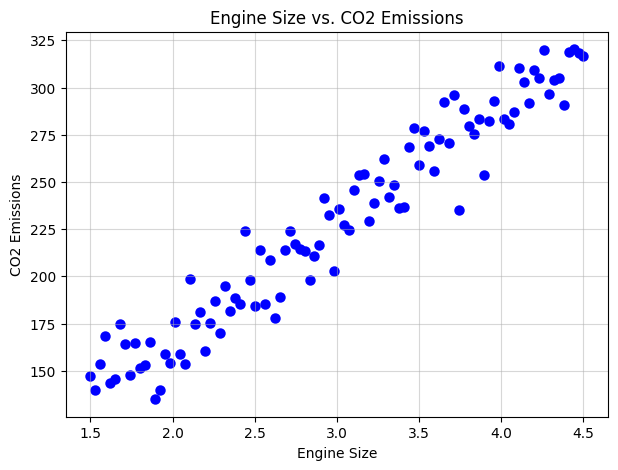

In [14]:
plt.figure(figsize=(7, 5))    # Define el tamaño del lienzo 7x5 pulgadas

# .scatter() crea un gráfico de dispersión (toma registros col. Engine size , registros col. CO2_emissions, colores azul en puntos , grosor de puntos)
plt.scatter(df['Engine_size'], df['CO2_Emissions'], color='b', edgecolors='b', linewidths=1.5)
# nombre a etiquetas de los ejes dentro del gráfico de dispersión
plt.xlabel('Engine Size')
plt.ylabel('CO2 Emissions')
# titulo y cuadricula al gráfico
plt.title('Engine Size vs. CO2 Emissions')
plt.grid(alpha=0.5) # transparencia de cuadricula

plt.show()

### Paso 3: Datos de entrenamiento y datos de prueba

A continuación, debemos extraer las variables dependientes e independientes del conjunto de datos dado.

Para este caso las emisiones de C02 (y) depende del tamaño del motor (x).

In [15]:
x = df.iloc[:,:-1]  #  variable independiente (años de experiencia)
y = df.iloc[:,1:]   # variable dependiente (salario)

# un vector columna
print(x.shape)

(100, 1)


Ahora, dividimos el conjunto de tuplas de datos en dos conjuntos: datos de prueba y datos de entrenamiento.

In [16]:
# divide el dataset en "entrenamiento" y conjunto de "prueba"
from sklearn.model_selection import train_test_split  # importamos sklearn
# rain_test_split() se encarga de mantener la correspondencia entre los pares (x,y)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
# 80 entrenamiento , 20 para pruebas
print(x_train.shape)
print(y_test.shape)

(80, 1)
(20, 1)


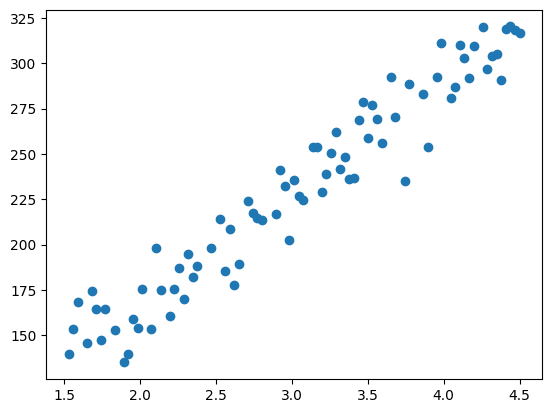

In [17]:
plt.scatter(x_train, y_train); # observamos nuestro data set de entrenamiento. (esta selección es con esta semilla --> "random_state=42")

### Paso 4: Entrenar el modelo

Después de definir el conjunto de datos de entrenamiento, procedemos con el ajuste de la recta que **mejor se aproxime** a los puntos graficados por los datos de entrenamiento (la mejor recta).

modelo: $\hat{y} = b_0 + b_1x$

Nota:
Si por alguna complicación no puedes transponer (de una forma unidimensional a una forma bidimensional con una sola columna) las matrices de los datos de entrenamiento, puedes usar este código. Es opcional, y se hace para evitar conflictos con ciertos algoritmos (métodos de librerias importadas) que esperan matrices bidimensionales.

*   x_tren = x_train.reshape(-1, 1)  --> (n, 1)
*   y_tren = y_train.reshape(-1, 1)  --> (n, 1)





In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()     # Instancia de la clase "LinearRegression"
model.fit(x_train, y_train)    # Calcula la mejor recta (obtenemos los parámetros lo más óptimo posible)

model.coef_  # b1


array([[60.6042018]])

In [19]:
model.intercept_  # b0

array([46.3904755])

In [20]:
# predicción de prueba y entrenamiento

x_pred = model.predict(x_train)
y_pred = model.predict(x_test)

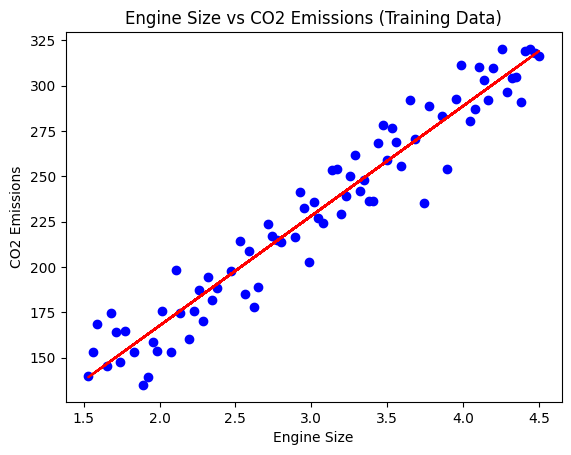

In [21]:
plt.scatter(x_train, y_train,color='blue')
plt.plot(x_train, x_pred, color= 'red')

plt.title("Engine Size vs CO2 Emissions (Training Data)")
plt.xlabel('Engine Size')
plt.ylabel('CO2 Emissions')
plt.show()

El modelo aprende las correlaciones entre las variables predictoras (independientes) y objetivo (dependientes).

### Paso 5: Probar el modelo

Creamos la recta bajo el entrenamiento del modelo con enfoque en una regresión lineal Simple, sobre el conjunto de datos de prueba que definimos antes al tomar una parte de los datos.

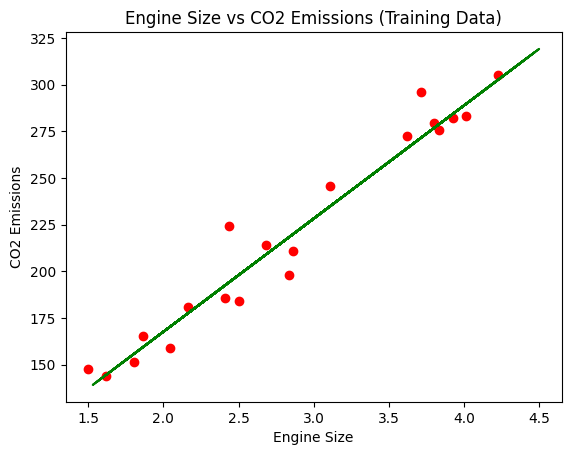

In [22]:
plt.scatter(x_test, y_test,color='red')  # Graficamos los puntos con los datos del conjunto de testing
plt.plot(x_train, x_pred, color= 'green')   # Recta construida by modelo entrenado

plt.title("Engine Size vs CO2 Emissions (Training Data)")
plt.xlabel('Engine Size')
plt.ylabel('CO2 Emissions')
plt.show()

Como podemos observar, aparentemente el modelo se acerca lo mayor posible a los datos, o sea es un buen modelo de aprendizaje.

Nota: Aún falta comprobar sobre el modelo, "métricas de efectividad" para asegurar que realmente presenta un "buen fit" o ajuste a los datos.